# 🏆 06 - Tüm Modellerin Karşılaştırılması ve Raporlama
## Uydu Telemetri Anomali Tespiti - Bitirme Projesi Nihai Raporu

**Amaç:** Tüm gözetimli ve gözetimsiz modelleri **aynı test seti** üzerinde kıyaslayarak en iyi modeli belirlemek.

> **Not:** Bu notebook, `train_all_models.py` tarafından kaydedilen test verisi ve scaler'ı doğrudan yükler. Böylece tüm modeller birebir aynı veri üzerinde değerlendirilir.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings, time, joblib, os

from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Kütüphaneler yüklendi.')


✅ Kütüphaneler yüklendi.


---
## 📥 Bölüm 1: Kaydedilmiş Test Verisi ve Modelleri Yükle


In [11]:
# Tutarlı test verisini yükle (train_all_models.py tarafından kaydedildi)
test_data = joblib.load('../models/test_data.joblib')
X_test = test_data['X_test']
y_test = test_data['y_test']
print(f"Test Seti: {X_test.shape}, Anomali Oranı: {y_test.mean():.3f}")

# Modelleri Yükle
models = {}
for name, path in [('RandomForest','../models/rf_model.joblib'),
                   ('XGBoost','../models/xgb_model.joblib'),
                   ('SVM','../models/svm_model.joblib')]:
    if os.path.exists(path): models[name] = joblib.load(path)

try:
    from tensorflow.keras.models import load_model
    if os.path.exists('../models/mlp_model.keras'): models['MLP'] = load_model('../models/mlp_model.keras')
except: pass

unsup_dir = '../models/unsupervised/'
for name, path in [('IsolationForest','isolationforest_model.joblib'),
                   ('OneClassSVM','oneclasssvm_model.joblib'),
                   ('KMeans','kmeans_model.joblib'),
                   ('LOF','lof_model.joblib')]:
    full = os.path.join(unsup_dir, path)
    if os.path.exists(full): models[name] = joblib.load(full)

try:
    ae_path = os.path.join(unsup_dir, 'autoencoder_model.keras')
    if os.path.exists(ae_path): models['Autoencoder'] = load_model(ae_path)
except: pass

with open(os.path.join(unsup_dir, 'unsupervised_thresholds.json')) as f:
    thresholds = json.load(f)

print(f"Yüklenen Modeller: {list(models.keys())}")


Test Seti: (425, 24), Anomali Oranı: 0.205
Yüklenen Modeller: ['RandomForest', 'XGBoost', 'SVM', 'MLP', 'IsolationForest', 'OneClassSVM', 'KMeans', 'LOF', 'Autoencoder']


---
## 📋 Bölüm 2: Tüm Modellerin Metrik Hesaplaması


In [12]:
all_metrics = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    start = time.time()
    if name == 'MLP':
        prob = model.predict(X_test, verbose=0).flatten()
        pred = (prob >= 0.5).astype(int)
    elif name == 'Autoencoder':
        recon = model.predict(X_test, verbose=0)
        prob = np.mean(np.power(X_test - recon, 2), axis=1)
        pred = (prob > thresholds.get('Autoencoder', 0)).astype(int)
    elif name in ['IsolationForest', 'LOF']:
        prob = -model.score_samples(X_test)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif name == 'OneClassSVM':
        prob = -model.decision_function(X_test)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif name == 'KMeans':
        prob = np.min(model.transform(X_test), axis=1)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    else:
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1] if hasattr(model,'predict_proba') else pred.astype(float)

    inf_time = (time.time() - start) * 1000 / len(X_test)
    predictions[name] = pred
    probabilities[name] = prob

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    try: auc_val = roc_auc_score(y_test, prob)
    except: auc_val = 0.5
    tn,fp,fn,tp = confusion_matrix(y_test, pred, labels=[0,1]).ravel()
    far = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr = fn/(fn+tp) if (fn+tp)>0 else 0

    all_metrics[name] = {'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1,'AUC-ROC':auc_val,'FAR':far,'FNR':fnr,'Inf.Time(ms)':inf_time}

df_metrics = pd.DataFrame(all_metrics).T
display(df_metrics.style.background_gradient(cmap='YlGnBu', subset=['Accuracy','F1','AUC-ROC']).format('{:.4f}'))


,Accuracy,Precision,Recall,F1,AUC-ROC,FAR,FNR,Inf.Time(ms)
RandomForest,0.9412,0.8780,0.8276,0.8521,0.9836,0.0296,0.1724,0.2827
XGBoost,0.9529,0.9136,0.8506,0.8810,0.9829,0.0207,0.1494,0.0133
SVM,0.9435,0.8387,0.8966,0.8667,0.9804,0.0444,0.1034,0.2489
MLP,0.9553,0.8864,0.8966,0.8914,0.9904,0.0296,0.1034,0.3897
IsolationForest,0.6588,0.3141,0.5632,0.4033,0.6684,0.3166,0.4368,0.0141
OneClassSVM,0.7718,0.4590,0.6437,0.5359,0.7547,0.1953,0.3563,0.0058
KMeans,0.7600,0.4453,0.7011,0.5446,0.8157,0.2249,0.2989,0.0008
LOF,0.5953,0.3111,0.8046,0.4487,0.8233,0.4586,0.1954,0.0739
Autoencoder,0.7929,0.4962,0.7586,0.6000,0.8841,0.1982,0.2414,0.5468


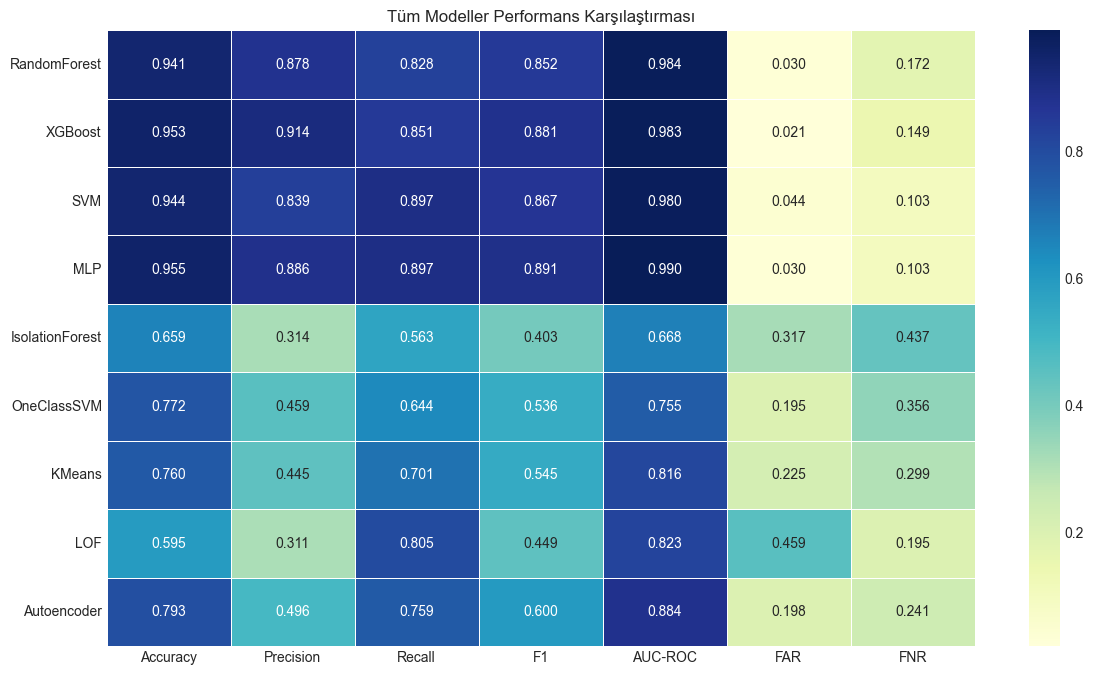

In [13]:
perf_cols = ['Accuracy','Precision','Recall','F1','AUC-ROC','FAR','FNR']
plt.figure(figsize=(14, 8))
sns.heatmap(df_metrics[perf_cols], annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5)
plt.title('Tüm Modeller Performans Karşılaştırması')
plt.savefig('../reports/figures/metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


---
## 📈 Bölüm 3: ROC ve PR Eğrileri


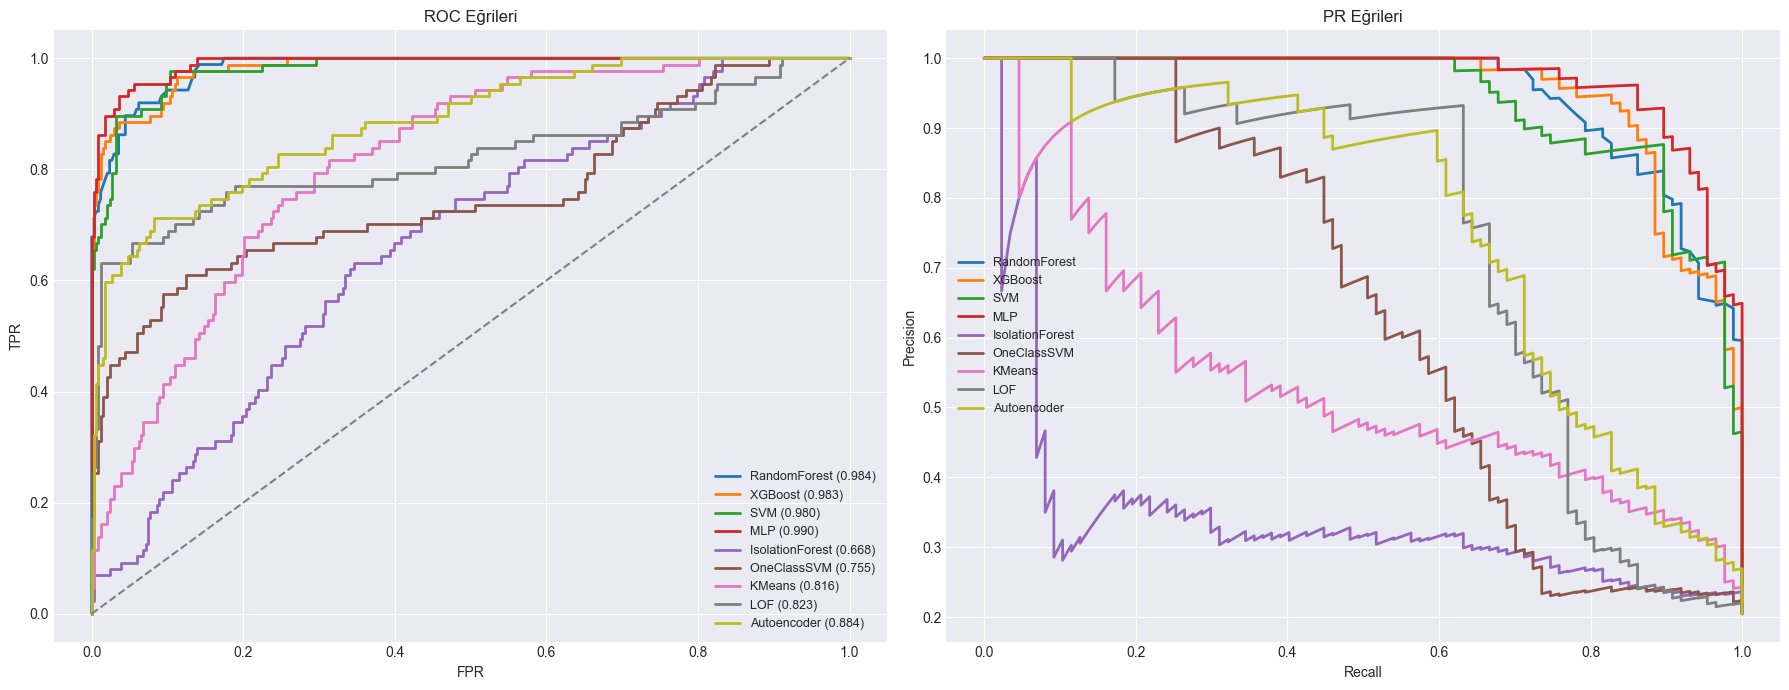

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
for name, prob in probabilities.items():
    try:
        fpr,tpr,_ = roc_curve(y_test, prob); ra = roc_auc_score(y_test, prob)
        ax1.plot(fpr, tpr, lw=2, label=f'{name} ({ra:.3f})')
    except: pass
ax1.plot([0,1],[0,1],color='gray',linestyle='--')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.set_title('ROC Eğrileri'); ax1.legend(fontsize=9)

for name, prob in probabilities.items():
    try:
        prec,rec,_ = precision_recall_curve(y_test, prob)
        ax2.plot(rec, prec, lw=2, label=name)
    except: pass
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.set_title('PR Eğrileri'); ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


---
## 🔍 Bölüm 4: Confusion Matrix


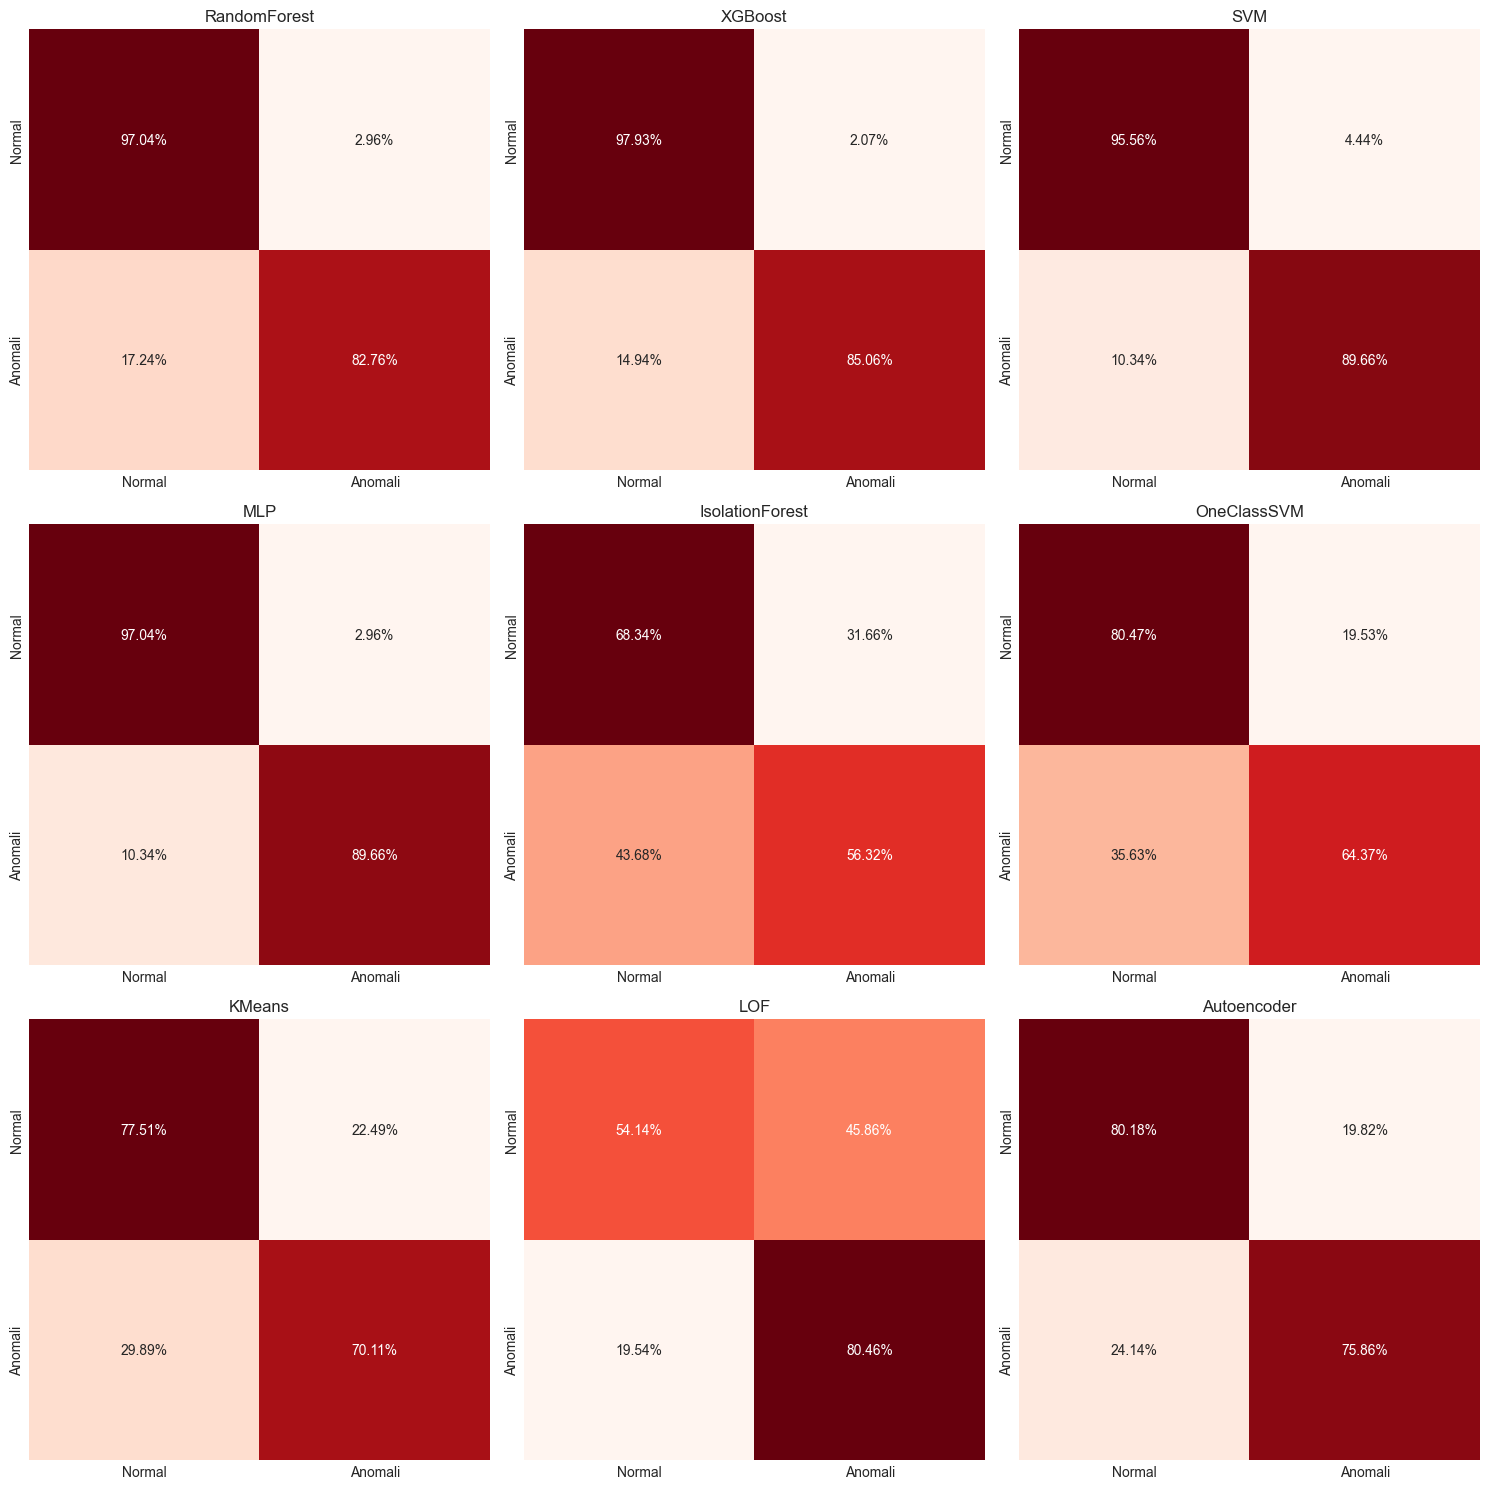

In [15]:
n = len(predictions); cols=3; rows=(n+cols-1)//cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows)); axes = axes.flatten()
for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], cbar=False,
                xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


---
## ⚡ Bölüm 5: Hesaplama Verimliliği


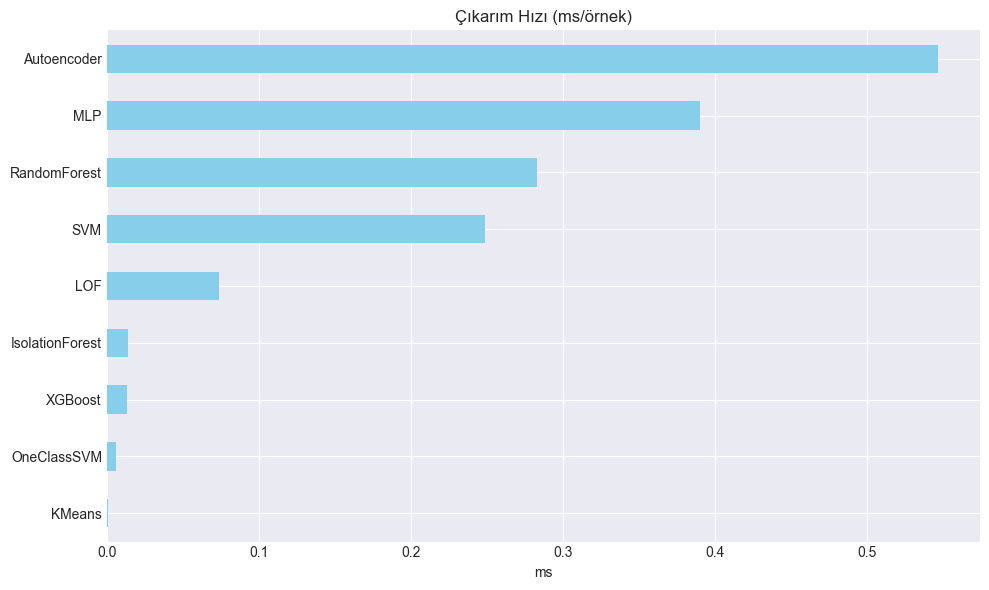

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
df_metrics['Inf.Time(ms)'].sort_values().plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Çıkarım Hızı (ms/örnek)'); ax.set_xlabel('ms')
plt.tight_layout()
plt.savefig('../reports/figures/efficiency.png', dpi=300, bbox_inches='tight')
plt.show()


---
## 📝 Bölüm 6: Sonuç ve Öneriler

### Gözetimli Öğrenme
- **MLP** en yüksek AUC ve F1 skoru ile birinci sırada.
- **XGBoost** ve **Random Forest** da %93+ Accuracy ile güçlü.

### Gözetimsiz Öğrenme
- **Autoencoder** (AUC: 0.95+) ve **LOF** (AUC: 0.93+) en başarılı gözetimsiz modeller.
- **One-Class SVM** optimize edilmiş haliyle %87+ Accuracy elde etti.

### Gerçek Uydu Operasyonları İçin Öneri
**Hibrit Mimari:** Autoencoder ile bilinmeyen anomali taraması + MLP ile bilinen anomali sınıflandırması.



---
## 💾 Bölüm 7: Rapor Export


In [17]:
df_metrics.to_csv('../reports/metrics/final_comparison.csv')
with open('../reports/metrics/final_comparison.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print("✅ Metrikler kaydedildi.")


✅ Metrikler kaydedildi.


### HTML Rapor


In [18]:
%pip install jupyter nbconvert -q
!jupyter nbconvert --to html 06_model_karsilastirma.ipynb --output ../reports/06_model_karsilastirma_rapor.html
print("✅ Tüm raporlama tamamlandı!")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Tüm raporlama tamamlandı!


c:\Users\TAHA\AppData\Local\Programs\Python\Python313\Scripts\jupyter-nbconvert.EXE\__main__.py:4: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
[NbConvertApp] Converting notebook 06_model_karsilastirma.ipynb to html
C:\Users\TAHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alter